# Notebook to investigate House Prices Tutorial Competition

In this notebook, I look into the tutorial competition for predicting house prices

## Code from Kaggle

The cell below was automatically generated when I created a new notebook. Let's ignore it for now

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
input_dir = '../input/'  # Use './' for submission
for dirname, _, filenames in os.walk(input_dir):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a
# version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

../input/house-prices-advanced-regression-techniques/test.csv
../input/house-prices-advanced-regression-techniques/data_description.txt
../input/house-prices-advanced-regression-techniques/train.csv
../input/house-prices-advanced-regression-techniques/sample_submission.csv


## Exploratory Data Analysis (EPA)

Let's dedicate some time to understand the data first.

### Reading in data

In [2]:
full_training = pd.read_csv(input_dir + 'house-prices-advanced-regression-techniques/train.csv',
                            keep_default_na=False  # Recall some of the categories are 'NA'
                            )
num_entries = full_training.shape[0]

print(f'Total number of entries in traning data = {num_entries}')

full_training.head(5)

Total number of entries in traning data = 1460


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65,8450,Pave,NA,Reg,Lvl,AllPub,...,0,NA,NA,NA,0,2,2008,WD,Normal,208500
1,2,20,RL,80,9600,Pave,NA,Reg,Lvl,AllPub,...,0,NA,NA,NA,0,5,2007,WD,Normal,181500
2,3,60,RL,68,11250,Pave,NA,IR1,Lvl,AllPub,...,0,NA,NA,NA,0,9,2008,WD,Normal,223500
3,4,70,RL,60,9550,Pave,NA,IR1,Lvl,AllPub,...,0,NA,NA,NA,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84,14260,Pave,NA,IR1,Lvl,AllPub,...,0,NA,NA,NA,0,12,2008,WD,Normal,250000


We can immediately see there are a lot of features here, some categorical (such as the `'MSZoning'`), and some continuous (such as the `'LotArea'`).

Recall the target variable is the sale price.

In [3]:
target_name = 'SalePrice'

### Just a hunch plot

Let's plot a few variables 

In [4]:
import matplotlib.pyplot as plt

We will first do a naive one: plot the target variable as a function of the lot area/size, and color it based on the zone class.

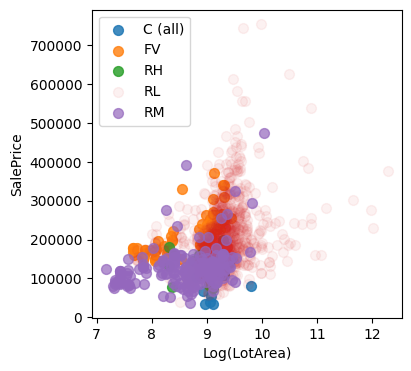

In [5]:
# Specify variables
continuous_var = 'LotArea'
categorical_var = 'MSZoning'

# Plot
fig, ax = plt.subplots(figsize=(4, 4))
ax.set_ylabel(target_name)
ax.set_xlabel(f'Log({continuous_var})')

for zone, data in full_training.groupby(categorical_var):
    sc = ax.scatter(np.log(data[continuous_var]), data[target_name],
                    # color=colors[zone],
                    marker='o',
                    alpha=(0.85 - len(data)/num_entries),  # The more entries the lighter for visualization purposes
                    s=50,
                    label=zone)
    # sc.set_facecolor("none")

_ = ax.legend()

The distribution of the target price appears to be not normal. Let's take a quick look.

### Target variable

Start by defining a helpful function to do this for us.

In [6]:
from typing import Dict

from matplotlib.figure import Figure
from matplotlib.axes import Axes

def view_stats(data: pd.Series,
               axes: Axes, 
               scale: float = 1.0,
               bins: int = 30,
               color: str = 'blue',
               alpha: float = 1.0,
               verbose: bool = True) -> Dict:
    """
    Auxiliary function to plot and compute helpful statistics of a certain column in the dataframe

    Args:
        data: Series of data to be used
        axes: axes to be used when plotting the histogram
        scale: scale value to apply before computing statistics; defaults to 1.
        bins: number of bins to be used in histogram plot; defaults to 30
        color: color to be used; defaults to blue
        alpha: opacity to be used; defaults to 1.0 (fully opaque)
        verbose: flag to indicate whether to print statistics or not; defaults to True

    Returns:
        a dictionary containining statistics
    """
    # Compute stats
    median = (scale * data).median()
    mean = (scale * data).mean()
    std = (scale * data).std()
    skew = (scale * data).skew()
    kurtosis = (scale * data).kurtosis()

    # Store in dict
    stats = {'median': median,
             'mean': mean,
             'std': std,
             'skew': skew,
             'kurtosis': kurtosis,
             'pre_scale': scale}

    # Plot
    data.hist(bins=bins, ax=axes, color=color, alpha=alpha)

    # Print info
    if verbose:
        for key, val in stats.items():
            print(f'{key.upper()}: {val}')

    return stats

Now, let's plot the values, but scale them down so we are dealing with "units" of a thousand dollars.

MEDIAN: 120.5
MEAN: 126.31683027522935
STD: 48.52168983254895
SKEW: 3.2639779947070338
KURTOSIS: 17.426504302416962
PRE_SCALE: 0.001


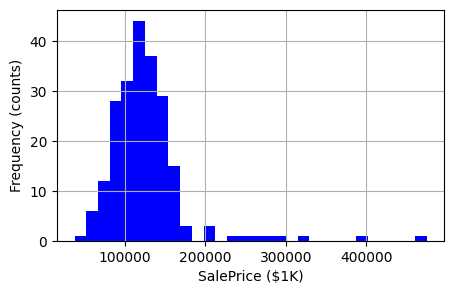

In [7]:
# Define the scaling parameter
scale=1.0e-03

# Create figure
fig, axes = plt.subplots(figsize=(5, 3))

target_stats = view_stats(data=data[target_name], axes=axes, scale=scale)
axes.set_xlabel(f'{target_name} ($1K)')
_ = axes.set_ylabel('Frequency (counts)')

This seems to be heavily skewed data. This is likely due to the outliers past the $400K mark. Let's see if a log transformation of the data makes it a bit more Gaussian.

In [8]:
log_target_name = f"log_{target_name}"

# Let's also apply the 1K scale here for simplicity
data.loc[:, log_target_name] = np.log(data[target_name] * scale)

MEDIAN: 4.791649752930709
MEAN: 4.785137330101994
STD: 0.31560537916783804
SKEW: 0.5096984276666682
KURTOSIS: 3.3156511713446317
PRE_SCALE: 1.0


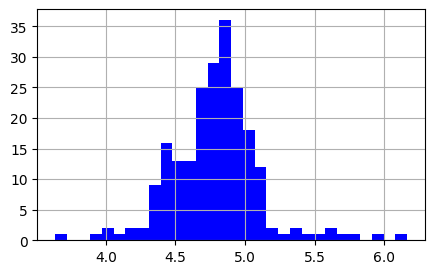

In [9]:
# Create figure
fig, axes = plt.subplots(figsize=(5, 3))

log_target_stats = view_stats(data=data[log_target_name], axes=axes)

This is good: it seems the log-transformed price is somewhat normally distributed, meaning it follows nice statistics for modeling.

Let's now move on to some of the other features.

### Feature analysis

We will now spend some time understanding the features of the data.

#### Missing data

We start by understanding how much data we are missing in our features.

In [ ]:
feats_with_missing_data = {}

for col in data.columns:
    if col == target_name or col == log_target_name:
        continue
    missing_perc = 100. * data[col].isna().sum() / num_entries
    if missing_perc > 0:
        print(f"Feature '{col}' missing {missing_perc:.2f}% of data")
        feats_with_missing_data[col] = missing_perc

print('=' * 120)
print(f'Total amount of features missing data = {len(feats_with_missing_data)}')

Total amount of features mmissing data = 0


That is excellent, we have no entries with missing features!

Some of these features are missing a lot of data, to the point that they should not be ignored. Let's start by seeing if this leads to a difference in the statistics of the target.

In [11]:
# Get features with a lot of missing data
large_missing_feats = [feats for feats, val in feats_with_missing_data.items() if val >= 5.]
num_large_missing_feats = len(large_missing_feats)

print(f'Number of features missing significant amout of data = {num_large_missing_feats}')

Number of features missing significant amout of data = 0


Seeing as there are only 6 of them, let's plot them all in a $2\times 3$ grid to see things better.

/var/folders/5h/0lh5q0792657fthclmvhk0tc0000gn/T/ipykernel_31131/1940901158.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  _ = axes[0, 0].legend()


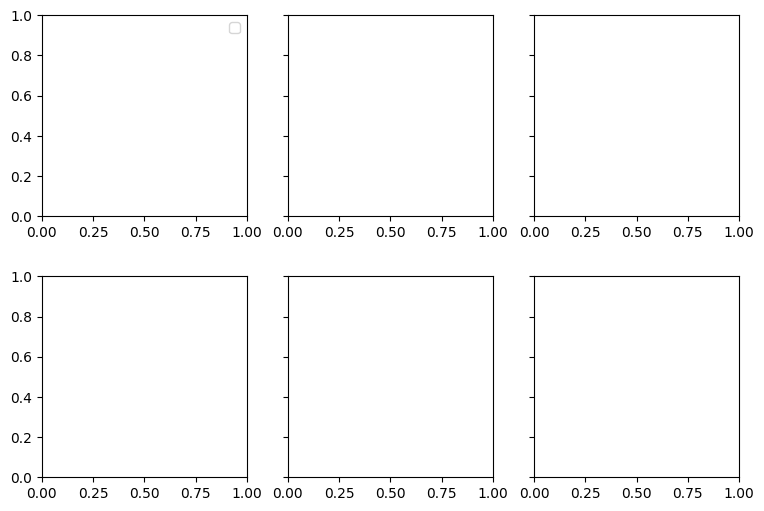

In [12]:
# Let's plot these
fig, axes = plt.subplots(2, 3, figsize=(9, 6), sharey='row')
fig.subplots_adjust(hspace=0.3)

for i, feat in enumerate(large_missing_feats):
    # Compute row and col number
    row = i // 3
    col = i % 3

    # Compute statistics for missing or not the feature
    missing_stats = view_stats(data=data[data[feat].isna()][log_target_name],
                               axes=axes[row, col],
                               color='red',
                               alpha=0.5,
                               verbose=False)
    present_stats = view_stats(data=data[~data[feat].isna()][log_target_name],
                               axes=axes[row, col],
                               color='blue',
                               alpha=0.5,
                               verbose=False)    

    # Plot means
    ylims = list(axes[row, col].get_ylim())
    axes[row, col].plot([missing_stats['mean'], missing_stats['mean']],
                        ylims,
                        color='red',
                        linestyle='--',
                        label='Missing')
    axes[row, col].plot([present_stats['mean'], present_stats['mean']],
                        ylims,
                        color='blue',
                        linestyle='--',
                        label='Present')

    # Set an informative title
    mean_diff_in_std = abs(missing_stats['mean'] - present_stats['mean']) / log_target_stats['std']
    axes[row, col].set_title(rf"{feat} $\Delta\mu=${mean_diff_in_std:.2f}")

_ = axes[0, 0].legend()

In [13]:
data[data['PoolQC'].isna()].head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,log_SalePrice
